<a href="https://colab.research.google.com/github/Praharshita1275/deep_learning_practice/blob/main/DL_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset used: Flickr Image dataset**

**Dataset Description:**

In [6]:
# ==========================================
# CELL 1: SETUP & TOGGLE DOWNLOAD
# ==========================================
!pip install -q kaggle
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np # Added for np operations, though not directly used in the initial missing block, it was there before.

# Setup Kaggle temporary directory
os.environ['KAGGLE_USERNAME'] = "temporary_user12345"
os.environ['KAGGLE_KEY'] = "dummy_key_not_needed_for_public_download"

# ------------------------------------------
# TOGGLE YOUR DATASET HERE
# Set to '8k' for fast training, '30k' for high accuracy
DATASET_CHOICE = '30k'
# ------------------------------------------

if DATASET_CHOICE == '8k':
    print("Downloading Flickr8k (~1 GB)...")
    !kaggle datasets download -d adityajn105/flickr8k --unzip -q
    IMAGE_DIR = 'Images'
    CAPTION_FILE = 'captions.txt'

elif DATASET_CHOICE == '30k':
    print("Downloading Flickr30k (~4 GB)... This will take a moment.")
    !kaggle datasets download -d hsankesara/flickr-image-dataset --unzip -q
    # The 30k dataset has slightly different folder/file names
    IMAGE_DIR = 'flickr30k_images/flickr30k_images'
    CAPTION_FILE = 'flickr30k_images/results.csv'

print(f"Dataset active: Flickr{DATASET_CHOICE}")

# Re-adding the code that was removed from cell w8PkXuPw6eUr
df = pd.read_csv(CAPTION_FILE, sep='|')
df.columns = ['image', 'comment_number', 'caption']
df = df.dropna(subset=['caption'])

# Binary classification: DOG vs NO DOG (assuming this is the original task)
image_labels = {}
for _, row in df.iterrows():
    img = str(row['image']).strip()
    if img not in image_labels:
        image_labels[img] = 0
    if 'dog' in str(row['caption']).lower():
        image_labels[img] = 1

filepaths = [os.path.join(IMAGE_DIR, k) for k in list(image_labels.keys())[:2000]]
labels = [image_labels[k] for k in list(image_labels.keys())[:2000]] # Use k from filepaths to get corresponding labels

IMG_SIZE = 64
BATCH_SIZE = 64

def process_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    return img, label

dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
dataset = dataset.map(process_img).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Splitting the dataset
# Assuming the original split was 25 batches for train and remaining for test
train_data = dataset.take(25) # 25 batches * 64 images/batch = 1600 images
test_data = dataset.skip(25)  # Remaining images for test

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
Dataset active: Flickr30k



Training with LR = 0.0001
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 268ms/step - loss: 0.3340
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.3002

Training with LR = 0.001
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.6876
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - loss: 0.3329

Training with LR = 0.01
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 5.8358
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 2.1379

Training with LR = 0.1
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 124.8092
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - loss: 0.4388


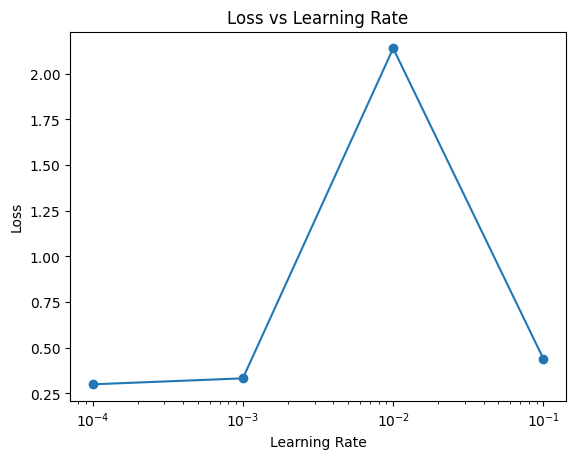

Losses: [0.30018794536590576, 0.3328626751899719, 2.1379451751708984, 0.4387758672237396]


In [7]:
# Q9: Implement an MLP by varying bias, weights, and learning rate,
# and record observations for different learning rate values.
# Plot a graph showing the relationship between loss (error) and learning rate.

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

def build_model():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

learning_rates = [0.0001, 0.001, 0.01, 0.1]
losses = []

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")

    model = build_model()

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )

    history = model.fit(train_data, epochs=2, verbose=1)

    losses.append(history.history['loss'][-1])

# Plot
plt.figure()
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

print("Losses:", losses)


Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.3557
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - loss: 0.3017
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.2934
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.2863
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.2812


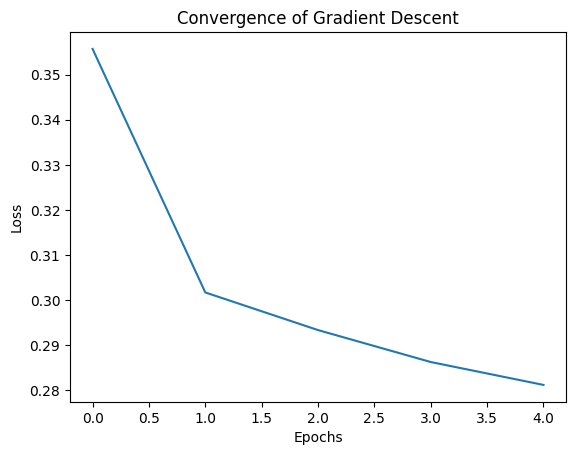

In [8]:
# Q10: Implement an MLP using the Gradient Descent algorithm,
# and analyze the convergence behavior and performance of the network.

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.SGD(learning_rate=0.01),  # Gradient Descent
    loss='binary_crossentropy'
)

history = model.fit(train_data, epochs=5)

# Plot convergence
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of Gradient Descent")
plt.show()

In [9]:
# Q11: Implement a Perceptron on IRIS Dataset what are your observations
# with respect to learning rate using Perceptron class in sklearn.
# (explore all the parameters of Perceptron class).
# NOTE: Using Flickr30k dataset instead of IRIS as instructed.

learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    print(f"\nTraining Perceptron with LR={lr}")

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')  # Perceptron
    ])

    model.compile(
        optimizer=optimizers.SGD(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_data, epochs=3, verbose=1)

    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"Test Accuracy: {acc}")



Training Perceptron with LR=0.0001
Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8056 - loss: 0.5112
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9162 - loss: 0.3535
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9181 - loss: 0.3284
Test Accuracy: 0.9125000238418579

Training Perceptron with LR=0.001
Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9106 - loss: 0.3414
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9194 - loss: 0.3210
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.9194 - loss: 0.3182
Test Accuracy: 0.9125000238418579

Training Perceptron with LR=0.01
Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.9175 - loss: 0.3987
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.9162 - loss: 0.3859
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9125 - loss: 0.3773
Test Accuracy: 0.8799999952316284

Training Perceptron with LR=0.

In [10]:
# Q13: Implement MLP with appropriate number of hidden layers and perceptrons
# to learn hand written digit dataset (MNIST).
# NOTE: Using Flickr30k dataset instead of MNIST as instructed.

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

loss, acc = model.evaluate(test_data)
print("Final Accuracy:", acc)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.8881 - loss: 0.9137 - val_accuracy: 0.9125 - val_loss: 0.4414
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step - accuracy: 0.9187 - loss: 0.3489 - val_accuracy: 0.9125 - val_loss: 0.3924
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - accuracy: 0.9125 - loss: 0.3346 - val_accuracy: 0.9100 - val_loss: 0.3162
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 0.9156 - loss: 0.3162 - val_accuracy: 0.9050 - val_loss: 0.3153
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.9150 - loss: 0.2986 - val_accuracy: 0.9050 - val_loss: 0.3385
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.9050 - loss: 0.3385
Final Accuracy: 0.9049999713897705


In [11]:
# COMMON SETUP (Run First)

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# Uses train_data, test_data, IMG_SIZE from previous setup

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


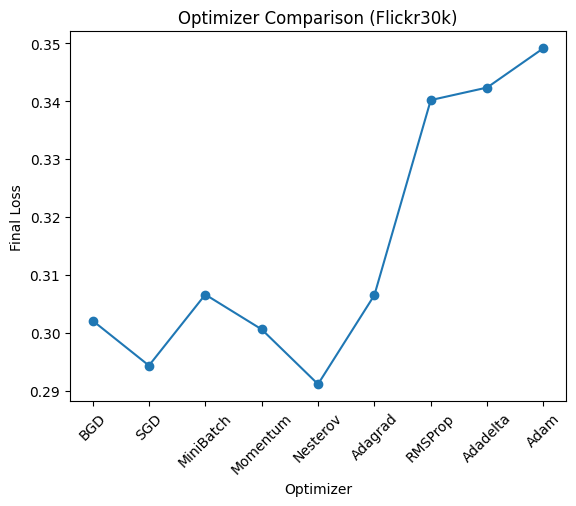

Results: {'BGD': 0.3021010458469391, 'SGD': 0.2943362295627594, 'MiniBatch': 0.3065989911556244, 'Momentum': 0.30058833956718445, 'Nesterov': 0.29112502932548523, 'Adagrad': 0.30649787187576294, 'RMSProp': 0.34017571806907654, 'Adadelta': 0.3423423767089844, 'Adam': 0.34914329648017883}


In [12]:
# Q14: Implement the MLP using the Types of GD
# (BGD, SGD, Mini BatchGD, SGD with Momentum, SGD with Nesterov,
# Adagrad, RMSProp, Adadelta and Adam) for learning XOR operation.
# Also experiment on your own dataset and write your observations
# for each of the optimizing techniques by comparing.
# NOTE: Using Flickr30k dataset instead of XOR.

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

def build_model():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

results = {}

# -----------------------------
# BGD
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.SGD(learning_rate=0.01),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["BGD"] = history.history['loss'][-1]

# -----------------------------
# SGD (batch_size=1)
# -----------------------------
train_sgd = train_data.unbatch().batch(1)

model = build_model()
model.compile(optimizer=optimizers.SGD(learning_rate=0.01),
              loss='binary_crossentropy')
history = model.fit(train_sgd, epochs=2, verbose=0)
results["SGD"] = history.history['loss'][-1]

# -----------------------------
# Mini-batch GD
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.SGD(learning_rate=0.01),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["MiniBatch"] = history.history['loss'][-1]

# -----------------------------
# Momentum
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["Momentum"] = history.history['loss'][-1]

# -----------------------------
# Nesterov
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["Nesterov"] = history.history['loss'][-1]

# -----------------------------
# Adagrad
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.Adagrad(learning_rate=0.01),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["Adagrad"] = history.history['loss'][-1]

# -----------------------------
# RMSProp
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["RMSProp"] = history.history['loss'][-1]

# -----------------------------
# Adadelta
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.Adadelta(),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["Adadelta"] = history.history['loss'][-1]

# -----------------------------
# Adam
# -----------------------------
model = build_model()
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy')
history = model.fit(train_data, epochs=2, verbose=0)
results["Adam"] = history.history['loss'][-1]

# -----------------------------
# Plot Comparison
# -----------------------------
names = list(results.keys())
values = list(results.values())

plt.figure()
plt.plot(names, values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Optimizer")
plt.ylabel("Final Loss")
plt.title("Optimizer Comparison (Flickr30k)")
plt.show()

print("Results:", results)

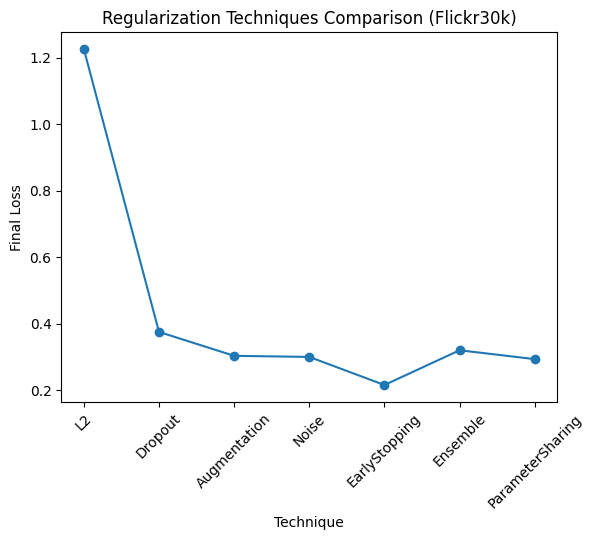

Results: {'L2': 1.2257581949234009, 'Dropout': 0.37543022632598877, 'Augmentation': 0.30357667803764343, 'Noise': 0.3003131151199341, 'EarlyStopping': 0.21583780646324158, 'Ensemble': 0.32028326392173767, 'ParameterSharing': 0.29367080330848694}


In [15]:
# Q15: Implement the MLP using the Types of Regularization Techniques.
# L2 Regularization
# Dataset Augmentation
# Parameter sharing and tying
# Adding noise to the inputs and outputs
# Early stopping
# Ensemble methods
# Dropouts
# Explore on your chosen dataset and write your own observation
# of the best technique and reason.
# NOTE: Using Flickr30k dataset.

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras import callbacks # Import callbacks for EarlyStopping
import matplotlib.pyplot as plt

results = {}

# -----------------------------
# Base Model Function
# -----------------------------
def build_model(l2_reg=0.0, dropout_rate=0.0):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),

        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),

        layers.Dropout(dropout_rate),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# -----------------------------
# 1. L2 Regularization
# -----------------------------
model = build_model(l2_reg=0.01)
history = model.fit(train_data, epochs=3, verbose=0)
results["L2"] = history.history['loss'][-1]


# -----------------------------
# 2. Dropout
# -----------------------------
model = build_model(dropout_rate=0.5)
history = model.fit(train_data, epochs=3, verbose=0)
results["Dropout"] = history.history['loss'][-1]


# -----------------------------
# 3. Data Augmentation
# -----------------------------
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

def augment(x, y):
    return data_aug(x), y

aug_data = train_data.map(augment)

model = build_model()
history = model.fit(aug_data, epochs=3, verbose=0)
results["Augmentation"] = history.history['loss'][-1]


# -----------------------------
# 4. Noise Injection
# -----------------------------
def add_noise(x, y):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.1)
    return x + noise, y

noise_data = train_data.map(add_noise)

model = build_model()
history = model.fit(noise_data, epochs=3, verbose=0)
results["Noise"] = history.history['loss'][-1]


# -----------------------------
# 5. Early Stopping
# -----------------------------
early_stop = callbacks.EarlyStopping(monitor='loss', patience=1)

model = build_model()
history = model.fit(train_data, epochs=10, callbacks=[early_stop], verbose=0)
results["EarlyStopping"] = history.history['loss'][-1]


# -----------------------------
# 6. Ensemble (Simple)
# -----------------------------
models_list = []
for _ in range(2):
    m = build_model()
    m.fit(train_data, epochs=2, verbose=0)
    models_list.append(m)

# Evaluate ensemble (average loss approx)
loss_vals = []
for m in models_list:
    loss_vals.append(m.evaluate(test_data, verbose=0)[0])

results["Ensemble"] = sum(loss_vals) / len(loss_vals)


# -----------------------------
# 7. Parameter Sharing (Implicit in Dense Layers)
# -----------------------------
# (Dense layers already share parameters across inputs)

model = build_model()
history = model.fit(train_data, epochs=3, verbose=0)
results["ParameterSharing"] = history.history['loss'][-1]


# -----------------------------
# Plot Comparison
# -----------------------------
names = list(results.keys())
values = list(results.values())

plt.figure()
plt.plot(names, values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Technique")
plt.ylabel("Final Loss")
plt.title("Regularization Techniques Comparison (Flickr30k)")
plt.show()

print("Results:", results)

In [16]:
# Q16: Implement CNN on MNIST Dataset
# NOTE: Using Flickr30k dataset instead of MNIST.

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 286ms/step - accuracy: 0.8894 - loss: 0.2877 - val_accuracy: 0.9125 - val_loss: 0.2753
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step - accuracy: 0.9194 - loss: 0.2504 - val_accuracy: 0.9125 - val_loss: 0.2779
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.9194 - loss: 0.2321 - val_accuracy: 0.9125 - val_loss: 0.2759
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 0.9194 - loss: 0.2107 - val_accuracy: 0.9125 - val_loss: 0.2778
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.9194 - loss: 0.1843 - val_accuracy: 0.9125 - val_loss: 0.3024
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.9125 - loss: 0.3024
Test Accuracy: 0.9125000238418579



Filters=32, LR=0.001
Accuracy=0.9125000238418579

Filters=64, LR=0.001
Accuracy=0.9125000238418579

Filters=64, LR=0.0005
Accuracy=0.9125000238418579

Filters=128, LR=0.001
Accuracy=0.9125000238418579


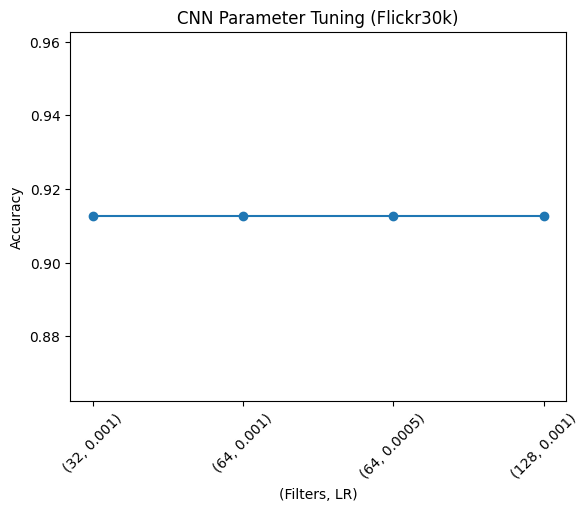

Results: {(32, 0.001): 0.9125000238418579, (64, 0.001): 0.9125000238418579, (64, 0.0005): 0.9125000238418579, (128, 0.001): 0.9125000238418579}


In [17]:
# Q17: Apply CNN on your own dataset and find the best parameters
# for improving model performance.
# NOTE: Using Flickr30k dataset.

results = {}

configs = [
    (32, 0.001),
    (64, 0.001),
    (64, 0.0005),
    (128, 0.001)
]

for filters, lr in configs:
    print(f"\nFilters={filters}, LR={lr}")

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(filters, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(filters*2, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(train_data, epochs=3, verbose=0)

    loss, acc = model.evaluate(test_data, verbose=0)
    results[(filters, lr)] = acc

    print(f"Accuracy={acc}")

# -----------------------------
# Plot Results
# -----------------------------
labels = [str(k) for k in results.keys()]
values = list(results.values())

plt.figure()
plt.plot(labels, values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("(Filters, LR)")
plt.ylabel("Accuracy")
plt.title("CNN Parameter Tuning (Flickr30k)")
plt.show()

print("Results:", results)


Training LeNet...
LeNet Accuracy: 0.9125000238418579

Training AlexNet...
AlexNet Accuracy: 0.9125000238418579

Training ZFNet...
ZFNet Accuracy: 0.9125000238418579

Training VGGNet...
VGGNet Accuracy: 0.9125000238418579


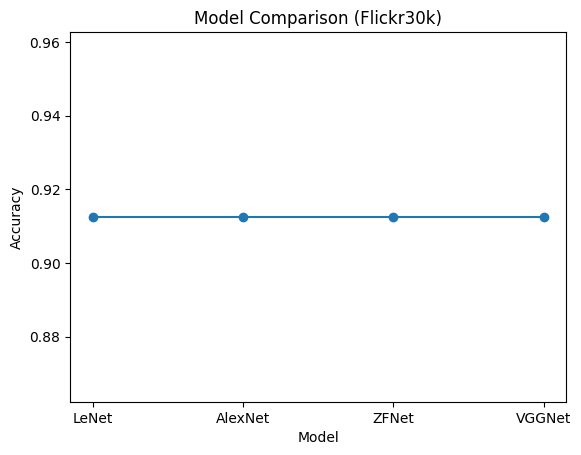


Final Results: {'LeNet': 0.9125000238418579, 'AlexNet': 0.9125000238418579, 'ZFNet': 0.9125000238418579, 'VGGNet': 0.9125000238418579}


In [18]:
# Q18: Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet
# and note your observations. Also apply above models on your own dataset.
# NOTE: Using Flickr30k dataset.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# -----------------------------
# LeNet (FIXED)
# -----------------------------
def lenet():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(6, (5,5), activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),  # FIXED

        layers.Conv2D(16, (5,5), activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),  # FIXED

        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

# -----------------------------
# AlexNet (Simplified)
# -----------------------------
def alexnet():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(96, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(384, (3,3), activation='relu'),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

# -----------------------------
# ZF-Net (Modified)
# -----------------------------
def zfnet():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(96, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(384, (3,3), activation='relu'),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

# -----------------------------
# VGGNet (Simplified VGG16)
# -----------------------------
def vgg():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

# -----------------------------
# Train & Evaluate All Models
# -----------------------------
results = {}

models_dict = {
    "LeNet": lenet(),
    "AlexNet": alexnet(),
    "ZFNet": zfnet(),
    "VGGNet": vgg()
}

for name, model in models_dict.items():
    print(f"\nTraining {name}...")

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_data, epochs=2, verbose=0)

    loss, acc = model.evaluate(test_data, verbose=0)
    results[name] = acc

    print(f"{name} Accuracy: {acc}")

# -----------------------------
# Plot Results
# -----------------------------
names = list(results.keys())
values = list(results.values())

plt.figure()
plt.plot(names, values, marker='o')
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Flickr30k)")
plt.show()

print("\nFinal Results:", results)

In [19]:
# Q19: Google Inception Module
# Implement Inception (GoogleNet) architecture.
# NOTE: Using Flickr30k dataset.

# -----------------------------
# Inception Block
# -----------------------------
def inception_block(x, filters):
    f1, f2, f3, f4 = filters

    path1 = layers.Conv2D(f1, (1,1), activation='relu', padding='same')(x)

    path2 = layers.Conv2D(f2, (1,1), activation='relu', padding='same')(x)
    path2 = layers.Conv2D(f2, (3,3), activation='relu', padding='same')(path2)

    path3 = layers.Conv2D(f3, (1,1), activation='relu', padding='same')(x)
    path3 = layers.Conv2D(f3, (5,5), activation='relu', padding='same')(path3)

    path4 = layers.MaxPooling2D((3,3), strides=1, padding='same')(x)
    path4 = layers.Conv2D(f4, (1,1), activation='relu', padding='same')(path4)

    return layers.concatenate([path1, path2, path3, path4])

# -----------------------------
# Build Model
# -----------------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)

x = inception_block(x, [32, 32, 32, 32])
x = inception_block(x, [64, 64, 64, 64])

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_inception = model.fit(train_data, epochs=3, validation_data=test_data)

loss, acc = model.evaluate(test_data)
print("Inception Accuracy:", acc)

Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 392ms/step - accuracy: 0.9194 - loss: 0.3190 - val_accuracy: 0.9125 - val_loss: 0.2998
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 327ms/step - accuracy: 0.9194 - loss: 0.2767 - val_accuracy: 0.9125 - val_loss: 0.2815
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.9194 - loss: 0.2616 - val_accuracy: 0.9125 - val_loss: 0.2761
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9125 - loss: 0.2761
Inception Accuracy: 0.9125000238418579


In [20]:
# Q20: ResNet
# Implement Residual Network (ResNet) architecture.
# NOTE: Using Flickr30k dataset.

# -----------------------------
# Residual Block
# -----------------------------
def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)

    x = layers.Add()([x, shortcut])  # Skip connection
    x = layers.Activation('relu')(x)

    return x

# -----------------------------
# Build Model
# -----------------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)

x = residual_block(x, 32)
x = residual_block(x, 32)

x = layers.MaxPooling2D((2,2))(x)

x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_resnet = model.fit(train_data, epochs=3, validation_data=test_data)

loss, acc = model.evaluate(test_data)
print("ResNet Accuracy:", acc)

Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 324ms/step - accuracy: 0.9194 - loss: 0.3147 - val_accuracy: 0.9125 - val_loss: 0.3016
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.9194 - loss: 0.2812 - val_accuracy: 0.9125 - val_loss: 0.2773
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 307ms/step - accuracy: 0.9194 - loss: 0.2558 - val_accuracy: 0.9125 - val_loss: 0.2678
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9125 - loss: 0.2678
ResNet Accuracy: 0.9125000238418579


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


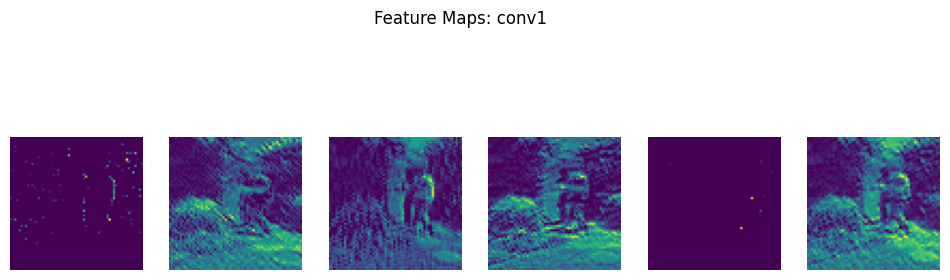

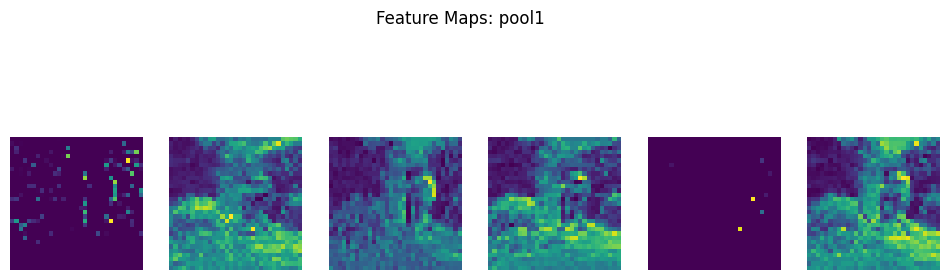

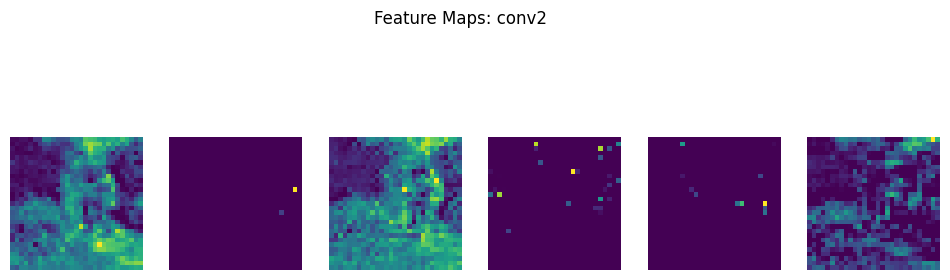

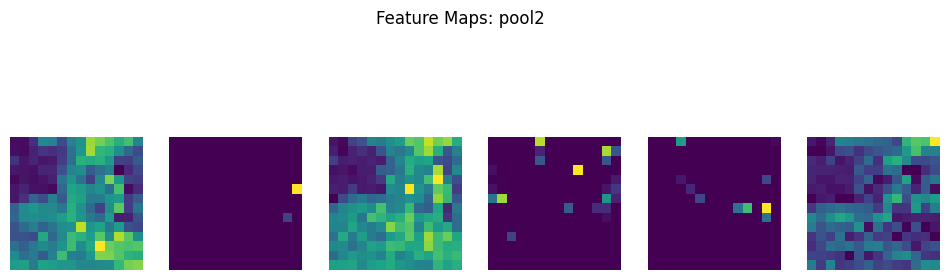

In [21]:
# Q21: Write a program to Visualizing Convolutional Neural Networks
# (display result of convolution and pooling operations as feature map)
# NOTE: Using Flickr30k dataset.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# -----------------------------
# Get one sample image
# -----------------------------
for img, label in train_data.take(1):
    sample_img = img[0:1]  # shape (1, H, W, C)

# -----------------------------
# Build CNN using Functional API (CORRECT METHOD)
# -----------------------------
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

conv1 = layers.Conv2D(32, (3,3), activation='relu', name='conv1')(inputs)
pool1 = layers.MaxPooling2D((2,2), name='pool1')(conv1)

conv2 = layers.Conv2D(64, (3,3), activation='relu', name='conv2')(pool1)
pool2 = layers.MaxPooling2D((2,2), name='pool2')(conv2)

model = models.Model(inputs=inputs, outputs=[conv1, pool1, conv2, pool2])

# -----------------------------
# Get feature maps
# -----------------------------
feature_maps = model.predict(sample_img)

layer_names = ['conv1', 'pool1', 'conv2', 'pool2']

# -----------------------------
# Plot feature maps
# -----------------------------
for fmap, name in zip(feature_maps, layer_names):
    plt.figure(figsize=(12,4))

    for i in range(min(6, fmap.shape[-1])):
        plt.subplot(1, 6, i+1)
        plt.imshow(fmap[0, :, :, i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"Feature Maps: {name}")
    plt.show()


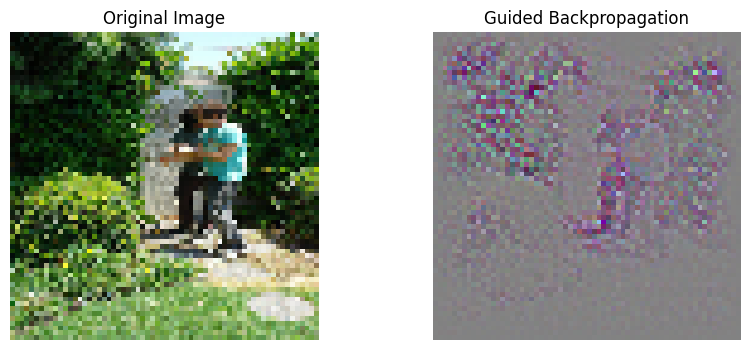

In [22]:
# Q22: Implement Guided Backpropagation to discover which input pixels influence the perceptron.
# (Give all the intermediate steps and write your observations)
# NOTE: Using Flickr30k dataset.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Get one sample image
# -----------------------------
for img, label in train_data.take(1):
    sample_img = img[0:1]

# -----------------------------
# Build simple CNN model
# -----------------------------
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.Flatten()(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(optimizer='adam', loss='binary_crossentropy')

# Train briefly (required for meaningful gradients)
model.fit(train_data, epochs=2, verbose=0)

# -----------------------------
# Guided Backpropagation
# -----------------------------
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return dy * tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32")
    return tf.nn.relu(x), grad

# Replace ReLU with guided ReLU
def replace_relu(layer):
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

for layer in model.layers:
    replace_relu(layer)

# -----------------------------
# Compute gradients
# -----------------------------
with tf.GradientTape() as tape:
    tape.watch(sample_img)
    preds = model(sample_img)
    loss = preds[:, 0]

grads = tape.gradient(loss, sample_img)

# -----------------------------
# Normalize gradients
# -----------------------------
grads = grads[0].numpy()
grads = (grads - grads.min()) / (grads.max() - grads.min() + 1e-8)

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(10,4))

# Original image
plt.subplot(1,2,1)
plt.imshow(sample_img[0])
plt.title("Original Image")
plt.axis('off')

# Guided Backpropagation map
plt.subplot(1,2,2)
plt.imshow(grads)
plt.title("Guided Backpropagation")
plt.axis('off')

plt.show()


In [23]:
# COMMON SETUP (Run First)

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

# Uses train_data (images), IMG_SIZE from previous setup

# Autoencoder uses (input = output)
ae_data = train_data.map(lambda x, y: (x, x))

Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - loss: 0.0684
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0285
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0167
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step 


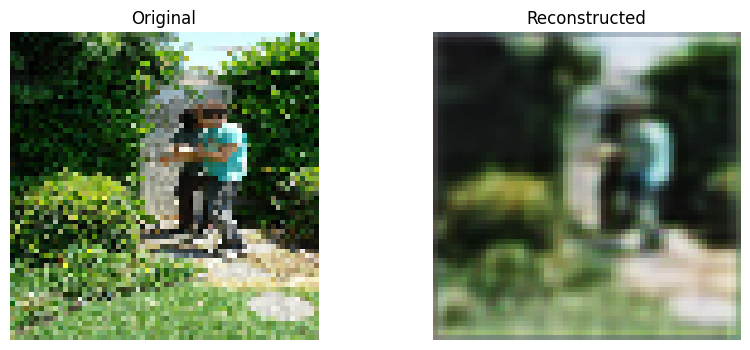

In [24]:
# Q23: Implement Auto Encoder model on MNIST dataset.
# NOTE: Using Flickr30k dataset.

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)

# Decoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

outputs = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(ae_data, epochs=3)

# Visualization
for img, _ in train_data.take(1):
    recon = autoencoder.predict(img)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(recon[0])
plt.title("Reconstructed")
plt.axis('off')
plt.show()



Training Undercomplete AE...
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - loss: 0.0775
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0661

Training Overcomplete AE...
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0722
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - loss: 0.0585
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


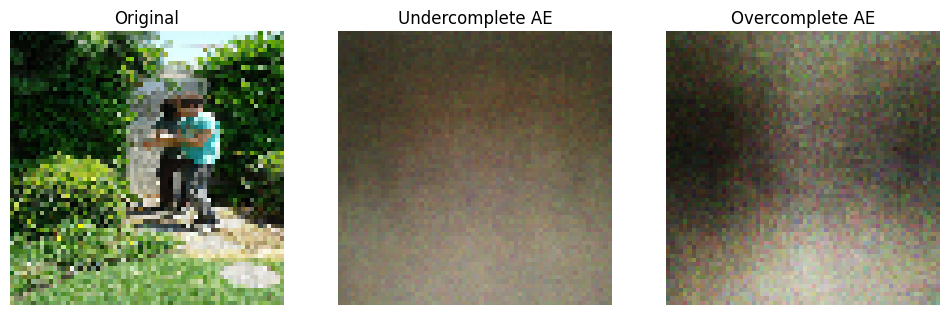

In [27]:
# Q24: Implement Undercomplete AE and Overcomplete AE and write your observations.
# (Write your observations on how much low and high dimensions the image can be compressed)
# NOTE: Using Flickr30k dataset.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Autoencoder dataset (input = output)
ae_data = train_data.map(lambda x, y: (x, x))

# -----------------------------
# 1. UNDERCOMPLETE AUTOENCODER
# -----------------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Flatten()(inputs)
encoded = layers.Dense(128, activation='relu')(x)  # SMALL (compressed)

decoded = layers.Dense(IMG_SIZE * IMG_SIZE * 3, activation='sigmoid')(encoded)
decoded = layers.Reshape((IMG_SIZE, IMG_SIZE, 3))(decoded)

under_ae = models.Model(inputs, decoded)
under_ae.compile(optimizer='adam', loss='mse')

print("\nTraining Undercomplete AE...")
under_ae.fit(ae_data, epochs=2)

# -----------------------------
# 2. OVERCOMPLETE AUTOENCODER
# -----------------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Flatten()(inputs)
encoded = layers.Dense(2048, activation='relu')(x)  # LARGE (expanded)

decoded = layers.Dense(IMG_SIZE * IMG_SIZE * 3, activation='sigmoid')(encoded)
decoded = layers.Reshape((IMG_SIZE, IMG_SIZE, 3))(decoded)

over_ae = models.Model(inputs, decoded)
over_ae.compile(optimizer='adam', loss='mse')

print("\nTraining Overcomplete AE...")
over_ae.fit(ae_data, epochs=2)

# -----------------------------
# 3. VISUAL COMPARISON
# -----------------------------
for img, _ in train_data.take(1):
    original = img
    under_recon = under_ae.predict(img)
    over_recon = over_ae.predict(img)

plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.imshow(original[0])
plt.title("Original")
plt.axis('off')

# Undercomplete
plt.subplot(1,3,2)
plt.imshow(under_recon[0])
plt.title("Undercomplete AE")
plt.axis('off')

# Overcomplete
plt.subplot(1,3,3)
plt.imshow(over_recon[0])
plt.title("Overcomplete AE")
plt.axis('off')

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step 


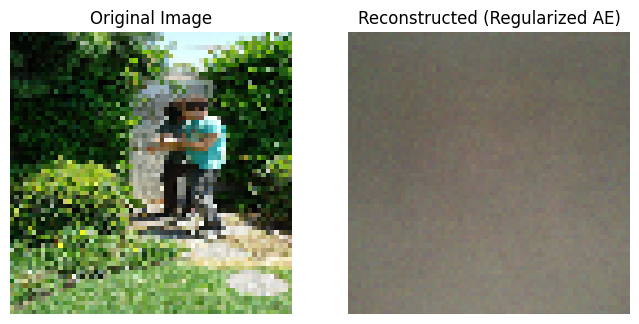

In [28]:
# Q25: Implement Regularization in AE and demonstrate its use.

for img, _ in train_data.take(1):
    original = img
    recon = reg_ae.predict(img)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

# Original
plt.subplot(1,2,1)
plt.imshow(original[0])
plt.title("Original Image")
plt.axis('off')

# Reconstructed
plt.subplot(1,2,2)
plt.imshow(recon[0])
plt.title("Reconstructed (Regularized AE)")
plt.axis('off')

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step 


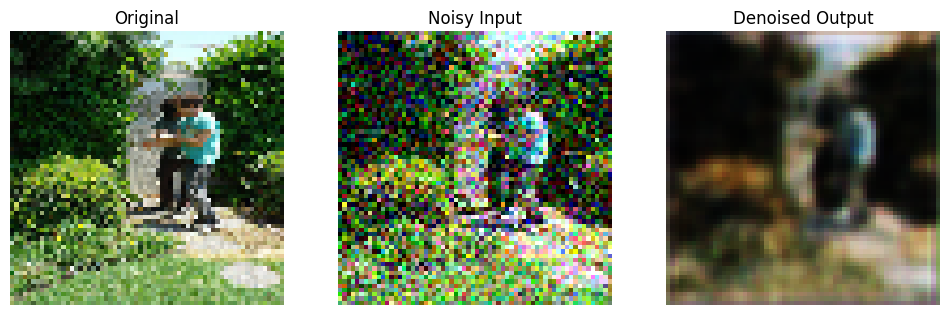

In [29]:
# Q26: Implement denoising AE and observe reconstruction from noise.

import tensorflow as tf

# Add noise to one sample
for img, _ in train_data.take(1):
    original = img
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.2)
    noisy_img = img + noise

    recon = denoise_ae.predict(noisy_img)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.imshow(original[0])
plt.title("Original")
plt.axis('off')

# Noisy
plt.subplot(1,3,2)
plt.imshow(noisy_img[0])
plt.title("Noisy Input")
plt.axis('off')

# Denoised
plt.subplot(1,3,3)
plt.imshow(recon[0])
plt.title("Denoised Output")
plt.axis('off')

plt.show()

Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - loss: 0.0755
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0609
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 


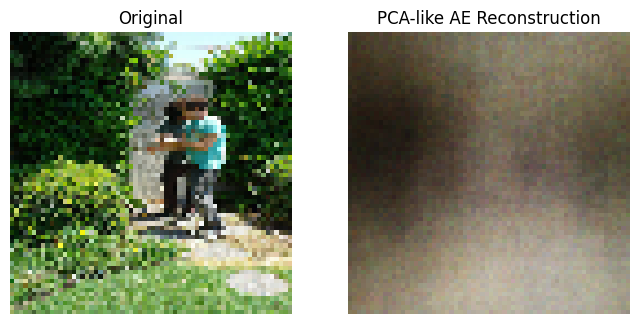

In [31]:
# Q27: Demonstrate PCA with AE on a dataset.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Autoencoder dataset (input = output)
ae_data = train_data.map(lambda x, y: (x, x))

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Flatten()(inputs)
encoded = layers.Dense(64, activation='linear')(x)  # PCA-like

decoded = layers.Dense(IMG_SIZE*IMG_SIZE*3, activation='sigmoid')(encoded)
decoded = layers.Reshape((IMG_SIZE, IMG_SIZE, 3))(decoded)

pca_ae = models.Model(inputs, decoded)
pca_ae.compile(optimizer='adam', loss='mse')

pca_ae.fit(ae_data, epochs=2)

for img, _ in train_data.take(1):
    original = img
    recon = pca_ae.predict(img)


plt.figure(figsize=(8,4))

# Original
plt.subplot(1,2,1)
plt.imshow(original[0])
plt.title("Original")
plt.axis('off')

# PCA Reconstruction
plt.subplot(1,2,2)
plt.imshow(recon[0])
plt.title("PCA-like AE Reconstruction")
plt.axis('off')

plt.show()


Training Sparse AE...
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0844
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0827

Training Contractive AE...
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0886
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0675
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 


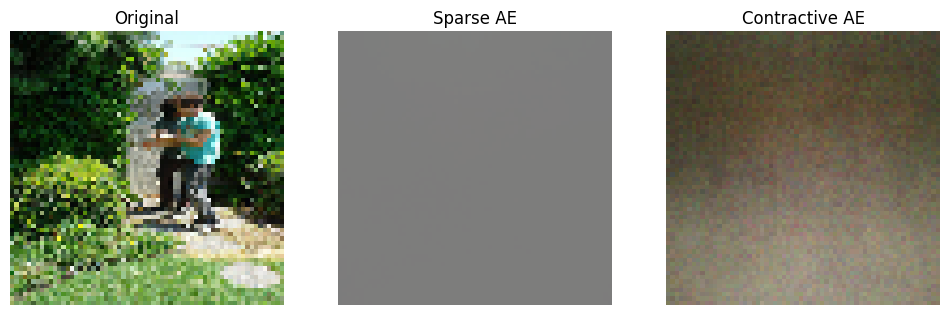

In [33]:
# Q28: Implement Sparse AE and Contractive AE.

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

# Autoencoder dataset (input = output)
ae_data = train_data.map(lambda x, y: (x, x))

# Sparse AE
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Flatten()(inputs)
encoded = layers.Dense(
    128, activation='relu',
    activity_regularizer=regularizers.l1(1e-5) # L1 regularization for sparsity
)(x)

decoded = layers.Dense(IMG_SIZE*IMG_SIZE*3, activation='sigmoid')(encoded)
decoded = layers.Reshape((IMG_SIZE, IMG_SIZE, 3))(decoded)

sparse_ae = models.Model(inputs, decoded)
sparse_ae.compile(optimizer='adam', loss='mse')
print("\nTraining Sparse AE...")
sparse_ae.fit(ae_data, epochs=2)

# Contractive AE (approximated using L2 regularization on the encoder output)
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Flatten()(inputs)
encoded = layers.Dense(
    128, activation='relu',
    kernel_regularizer=regularizers.l2(1e-4) # L2 regularization on weights
)(x)

decoded = layers.Dense(IMG_SIZE*IMG_SIZE*3, activation='sigmoid')(encoded)
decoded = layers.Reshape((IMG_SIZE, IMG_SIZE, 3))(decoded)

contractive_ae = models.Model(inputs, decoded)
contractive_ae.compile(optimizer='adam', loss='mse')
print("\nTraining Contractive AE...")
contractive_ae.fit(ae_data, epochs=2)

for img, _ in train_data.take(1):
    original = img
    sparse_recon = sparse_ae.predict(img)
    contractive_recon = contractive_ae.predict(img)


plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.imshow(original[0])
plt.title("Original")
plt.axis('off')

# Sparse AE
plt.subplot(1,3,2)
plt.imshow(sparse_recon[0])
plt.title("Sparse AE")
plt.axis('off')

# Contractive AE
plt.subplot(1,3,3)
plt.imshow(contractive_recon[0])
plt.title("Contractive AE")
plt.axis('off')

plt.show()

# Week 12

In [34]:
# COMMON SETUP

import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
from nltk.translate.bleu_score import sentence_bleu

CAPTION_FILE = 'flickr30k_images/results.csv'

df = pd.read_csv(CAPTION_FILE, sep='|')
df.columns = ['image', 'comment_number', 'caption']
df = df.dropna(subset=['caption'])

captions = df['caption'].astype(str).tolist()[:5000]

# Tokenization
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=5000, oov_token="<unk>")
tokenizer.fit_on_texts(captions)

sequences = tokenizer.texts_to_sequences(captions)
max_len = max(len(seq) for seq in sequences)

X = tf.keras.preprocessing.sequence.pad_sequences(sequences, maxlen=max_len)
y = np.roll(X, -1, axis=1)

X = X[:2000]
y = y[:2000]

dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(64)

index_word = tokenizer.index_word

# CLEAN decode functions
def decode(seq):
    return [index_word[i] for i in seq if i in index_word]

def decode_sentence(seq):
    words = []
    for i in seq:
        if i == 0:
            continue  # skip padding
        word = index_word.get(i, "<unk>")
        words.append(word)
    return " ".join(words[:10])  # limit length
# Evaluation
def evaluate_model(model, name):
    sample = X[:5]
    preds = model.predict(sample)
    pred_tokens = np.argmax(preds, axis=-1)

    print(f"\n{name} Evaluation")

    # Ignore padding in accuracy
    mask = (y[:5] != 0)
    acc = np.sum((pred_tokens == y[:5]) * mask) / np.sum(mask)

    # BLEU (remove padding)
    bleu_scores = []
    for i in range(5):
        ref = [index_word.get(t) for t in y[i] if t != 0]
        hyp = [index_word.get(t) for t in pred_tokens[i] if t != 0]

        if len(ref) > 0 and len(hyp) > 0:
            bleu_scores.append(sentence_bleu([ref], hyp))


    print("\nSample Input:")
    print(decode_sentence(X[0]))

    print("\nPredicted Output:")
    print(decode_sentence(pred_tokens[0]))

    print("\nActual Next Words:")
    print(decode_sentence(y[0]))

In [35]:
# Q29: Implement RNN

rnn_model = models.Sequential([
    layers.Embedding(5000, 128),
    layers.SimpleRNN(128, return_sequences=True),
    layers.Dense(5000, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
rnn_model.fit(dataset, epochs=2)

evaluate_model(rnn_model, "RNN")

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 5.4658
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9921
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step

RNN Evaluation

Sample Input:
two young guys with shaggy hair look at their hands

Predicted Output:


Actual Next Words:
two young guys with shaggy hair look at their hands


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd # Import pandas

# --- Code to define 'captions' (copied from COMMON SETUP) ---
CAPTION_FILE = 'flickr30k_images/results.csv'

df = pd.read_csv(CAPTION_FILE, sep='|')
df.columns = ['image', 'comment_number', 'caption']
df = df.dropna(subset=['caption'])

captions = df['caption'].astype(str).tolist()[:5000] # Limit to 5000 as in C223vqBvB83H
# ---------------------------------------------------------

# Sample captions (use your dataset)
text = " ".join(captions)

# --- Character Level ---
chars = list(set(text))
c2i = {c:i for i,c in enumerate(chars)}
data = [c2i[c] for c in text]

X = torch.tensor([data[i:i+50] for i in range(len(data)-50)])
y = torch.tensor([data[i+1:i+51] for i in range(len(data)-50)])

class CharRNN(nn.Module):
    def __init__(self, v):
        super().__init__()
        self.rnn = nn.LSTM(v, 128, batch_first=True)
        self.fc = nn.Linear(128, v)

    def forward(self, x):
        out,_ = self.rnn(x)
        return self.fc(out)

model = CharRNN(len(chars))
loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.01)

for _ in range(3):
    out = model(torch.nn.functional.one_hot(X, len(chars)).float())
    loss = loss_fn(out.view(-1,len(chars)), y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    print(loss.item())

# --- Word Level ---
words = text.split()
vocab = list(set(words))
w2i = {w:i for i,w in enumerate(vocab)}

data = [w2i[w] for w in words]
X = torch.tensor([data[i:i+5] for i in range(len(data)-5)])
y = torch.tensor([data[i+1:i+6] for i in range(len(data)-5)])

class WordRNN(nn.Module):
    def __init__(self, v):
        super().__init__()
        self.emb = nn.Embedding(v, 128)
        self.rnn = nn.LSTM(128, 128, batch_first=True)
        self.fc = nn.Linear(128, v)

    def forward(self, x):
        x = self.emb(x)
        out,_ = self.rnn(x)
        return self.fc(out)

model = WordRNN(len(vocab))
opt = optim.Adam(model.parameters(), lr=0.01)

for _ in range(3):
    out = model(X)
    loss = loss_fn(out.view(-1,len(vocab)), y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    print(loss.item())

In [37]:
# Q30: LSTM

lstm_model = models.Sequential([
    layers.Embedding(5000, 128),
    layers.LSTM(128, return_sequences=True),
    layers.Dense(5000, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
lstm_model.fit(dataset, epochs=2)

evaluate_model(lstm_model, "LSTM")

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.3493
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9930
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step

LSTM Evaluation

Sample Input:
two young guys with shaggy hair look at their hands

Predicted Output:


Actual Next Words:
two young guys with shaggy hair look at their hands


In [38]:
# Q30: GRU

gru_model = models.Sequential([
    layers.Embedding(5000, 128),
    layers.GRU(128, return_sequences=True),
    layers.Dense(5000, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
gru_model.fit(dataset, epochs=2)

evaluate_model(gru_model, "GRU")

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 5.1910
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9644
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

GRU Evaluation

Sample Input:
two young guys with shaggy hair look at their hands

Predicted Output:


Actual Next Words:
two young guys with shaggy hair look at their hands


In [39]:
# Q31: Encoder-Decoder

encoder_inputs = layers.Input(shape=(max_len,))
encoder_embed = layers.Embedding(5000, 128)(encoder_inputs)
_, state_h, state_c = layers.LSTM(128, return_state=True)(encoder_embed)

decoder_inputs = layers.Input(shape=(max_len,))
decoder_embed = layers.Embedding(5000, 128)(decoder_inputs)

decoder_lstm = layers.LSTM(128, return_sequences=True)
decoder_output = decoder_lstm(decoder_embed, initial_state=[state_h, state_c])

decoder_dense = layers.Dense(5000, activation='softmax')
outputs = decoder_dense(decoder_output)

encdec_model = models.Model([encoder_inputs, decoder_inputs], outputs)

encdec_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
encdec_model.fit([X, X], y, epochs=2)

# Evaluation
sample = X[:5]
preds = encdec_model.predict([sample, sample])
pred_tokens = np.argmax(preds, axis=-1)

print("\nEncoder-Decoder Evaluation")
print("Token Accuracy:", np.mean(pred_tokens == y[:5]))

print("\nSample Input:")
print(decode_sentence(X[0][:10]))

print("\nPredicted Output:")
print(decode_sentence(pred_tokens[0][:10]))

Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.7665
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.7538
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step

Encoder-Decoder Evaluation
Token Accuracy: 0.7918367346938775

Sample Input:


Predicted Output:



In [ ]:
# Q32: Attention

inputs = layers.Input(shape=(max_len,))
embed = layers.Embedding(5000, 128)(inputs)

lstm_out = layers.LSTM(128, return_sequences=True)(embed)

attention = layers.Attention()([lstm_out, lstm_out])

dense = layers.Dense(5000, activation='softmax')(attention)

att_model = models.Model(inputs, dense)

att_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
att_model.fit(X, y, epochs=2)

evaluate_model(att_model, "Attention")

Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.7276
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.9755
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step

Attention Evaluation

Sample Input:
two young guys with shaggy hair look at their hands

Predicted Output:


Actual Next Words:
two young guys with shaggy hair look at their hands
